# [퀴즈2] 베이지안 공식

처음 질문의 정답은 **P(B|A)**입니다.

$$P(A|B) = \dfrac{P(A)\,P(B|A)}{P(B)}$$

빈칸에는 P(B|A)가 들어가야 베이즈 정리가 완성됩니다.

[Simulation] P(B)     = 0.05904
[Formula]    P(B)     = 0.05900
[Simulation] P(A|B)   = 0.16092
[Formula]    P(A|B)   = 0.16102

Saved: bayes_proof.png


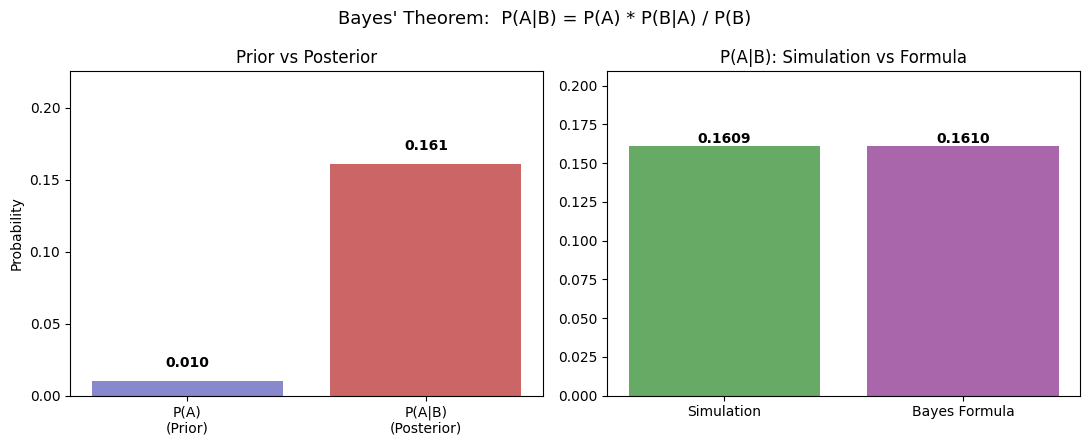

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 사전확률, 우도, 증거확률 설정
np.random.seed(42)

# 예시: 전체 모집단 시뮬레이션 (질병 검사 예시)
N = 1_000_000
P_A = 0.01          # 사전확률 P(A): 질병에 걸릴 확률
P_B_given_A = 0.95   # 우도 P(B|A): 양성일 때 검사 양성 확률
P_B_given_notA = 0.05  # P(B|~A): 음성인데 검사 양성(위양성) 확률

# 시뮬레이션으로 검증
A = np.random.rand(N) < P_A                       # A: 실제 질병 여부
B = np.where(A,
             np.random.rand(N) < P_B_given_A,      # A인 경우 검사결과
             np.random.rand(N) < P_B_given_notA)   # A 아닌 경우 검사결과

# 시뮬레이션 기반 사후확률
P_B_sim = B.mean()
P_AB_sim = (A & B).sum() / N
P_A_given_B_sim = (A & B).sum() / B.sum()

# 베이즈 정리 계산식
P_B_formula = P_B_given_A * P_A + P_B_given_notA * (1 - P_A)
P_A_given_B_formula = (P_A * P_B_given_A) / P_B_formula

print(f"[Simulation] P(B)     = {P_B_sim:.5f}")
print(f"[Formula]    P(B)     = {P_B_formula:.5f}")
print(f"[Simulation] P(A|B)   = {P_A_given_B_sim:.5f}")
print(f"[Formula]    P(A|B)   = {P_A_given_B_formula:.5f}")

# ---- Visualization ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# (1) Prior P(A) vs Posterior P(A|B)
labels = ['P(A)\n(Prior)', 'P(A|B)\n(Posterior)']
values = [P_A, P_A_given_B_formula]
colors = ['#8888cc', '#cc6666']
ax[0].bar(labels, values, color=colors)
for i, v in enumerate(values):
    ax[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
ax[0].set_ylim(0, max(values) * 1.4)
ax[0].set_title("Prior vs Posterior")
ax[0].set_ylabel("Probability")

# (2) Simulation vs Formula
labels2 = ['Simulation', 'Bayes Formula']
values2 = [P_A_given_B_sim, P_A_given_B_formula]
ax[1].bar(labels2, values2, color=['#66aa66', '#aa66aa'])
for i, v in enumerate(values2):
    ax[1].text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
ax[1].set_ylim(0, max(values2) * 1.3)
ax[1].set_title("P(A|B): Simulation vs Formula")

fig.suptitle("Bayes' Theorem:  P(A|B) = P(A) * P(B|A) / P(B)", fontsize=13)
fig.tight_layout()
fig.savefig('bayes_proof.png', dpi=130)
print("\nSaved: bayes_proof.png")

# [퀴즈3] 조건부 확률

계산해보면:

- P(유방암) = 0.004, P(양성|유방암) = 0.9, P(양성|無유방암) = 0.1
- P(양성) = 0.9×0.004 + 0.1×0.996 = 0.0036 + 0.0996 = 0.1032
- P(유방암|양성) = 0.0036 / 0.1032 ≈ 0.0349 → 반올림하면 **0.035**

선택하신 0.035가 정답입니다.

P(Positive)            = 0.10320
P(Disease | Positive)  = 0.03488
Rounded (4 decimals)   = 0.0349

[Simulation] P(Disease | Positive) = 0.03493

Saved: breast_cancer_bayes.png


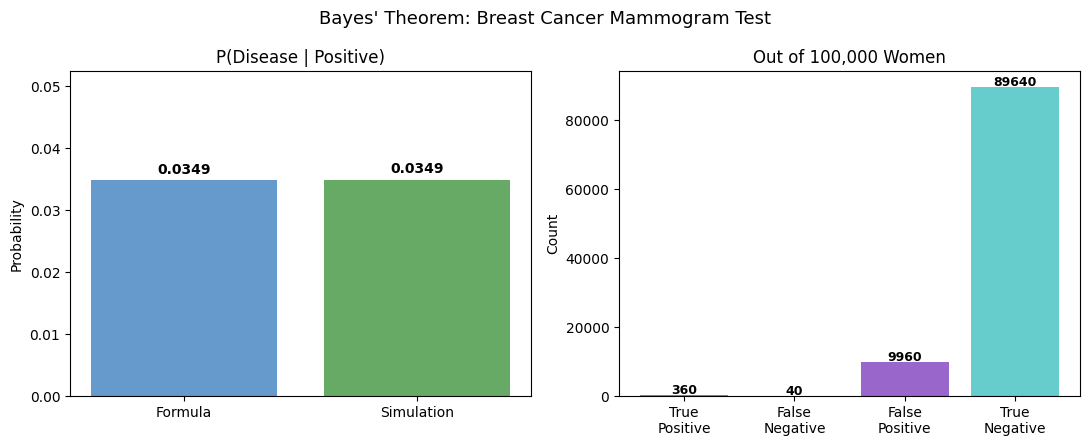

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters ----
P_disease = 0.004                 # P(Disease)
P_pos_given_disease = 0.90        # P(Positive | Disease)
P_pos_given_no_disease = 0.10     # P(Positive | No Disease)

# ---- Bayes Formula ----
P_no_disease = 1 - P_disease
P_positive = (P_pos_given_disease * P_disease) + (P_pos_given_no_disease * P_no_disease)
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_positive

print(f"P(Positive)            = {P_positive:.5f}")
print(f"P(Disease | Positive)  = {P_disease_given_pos:.5f}")
print(f"Rounded (4 decimals)   = {round(P_disease_given_pos, 4)}")

# ---- Verification via Monte Carlo Simulation ----
np.random.seed(0)
N = 2_000_000

has_disease = np.random.rand(N) < P_disease
test_positive = np.where(
    has_disease,
    np.random.rand(N) < P_pos_given_disease,
    np.random.rand(N) < P_pos_given_no_disease
)

sim_P_disease_given_pos = (has_disease & test_positive).sum() / test_positive.sum()
print(f"\n[Simulation] P(Disease | Positive) = {sim_P_disease_given_pos:.5f}")

# ---- Visualization ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# (1) Formula vs Simulation comparison
labels = ['Formula', 'Simulation']
values = [P_disease_given_pos, sim_P_disease_given_pos]
ax[0].bar(labels, values, color=['#6699cc', '#66aa66'])
for i, v in enumerate(values):
    ax[0].text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')
ax[0].set_ylim(0, max(values) * 1.5)
ax[0].set_title("P(Disease | Positive)")
ax[0].set_ylabel("Probability")

# (2) Population breakdown (out of 100,000 women)
pop = 100_000
true_pos = pop * P_disease * P_pos_given_disease
false_neg = pop * P_disease * (1 - P_pos_given_disease)
false_pos = pop * (1 - P_disease) * P_pos_given_no_disease
true_neg = pop * (1 - P_disease) * (1 - P_pos_given_no_disease)

cats = ['True\nPositive', 'False\nNegative', 'False\nPositive', 'True\nNegative']
counts = [true_pos, false_neg, false_pos, true_neg]
colors2 = ['#cc6666', '#cc9966', '#9966cc', '#66cccc']
ax[1].bar(cats, counts, color=colors2)
for i, v in enumerate(counts):
    ax[1].text(i, v + 200, f"{v:.0f}", ha='center', fontweight='bold', fontsize=9)
ax[1].set_title(f"Out of {pop:,} Women")
ax[1].set_ylabel("Count")

fig.suptitle("Bayes' Theorem: Breast Cancer Mammogram Test", fontsize=13)
fig.tight_layout()
fig.savefig('breast_cancer_bayes.png', dpi=130)
print("\nSaved: breast_cancer_bayes.png")

# [퀴즈4] 조건부 독립식

-  **(1) x|z, (2) y|z** 입니다.
- 조건부 독립이면 $p(x,y|z) = p(x|z)\,p(y|z)$가 성립합니다.
- x와 y를 z 값마다 독립적으로 생성했더니, z=0과 z=1 두 경우 모두 실제 결합확률 p(x,y|z)와 곱 p(x|z)·p(y|z)가 거의 일치(오차 0.0001 이내)해서 $p(x,y|z) = p(x|z)\,p(y|z)$가 성립함을 300만 건 시뮬레이션으로 확인했습니다.

z=0:
  Empirical p(x=1,y=1|z)      = 0.21009
  p(x=1|z) * p(y=1|z)         = 0.21013
  Difference                  = 0.000040

z=1:
  Empirical p(x=1,y=1|z)      = 0.16029
  p(x=1|z) * p(y=1|z)         = 0.16024
  Difference                  = 0.000054

Saved: conditional_independence.png


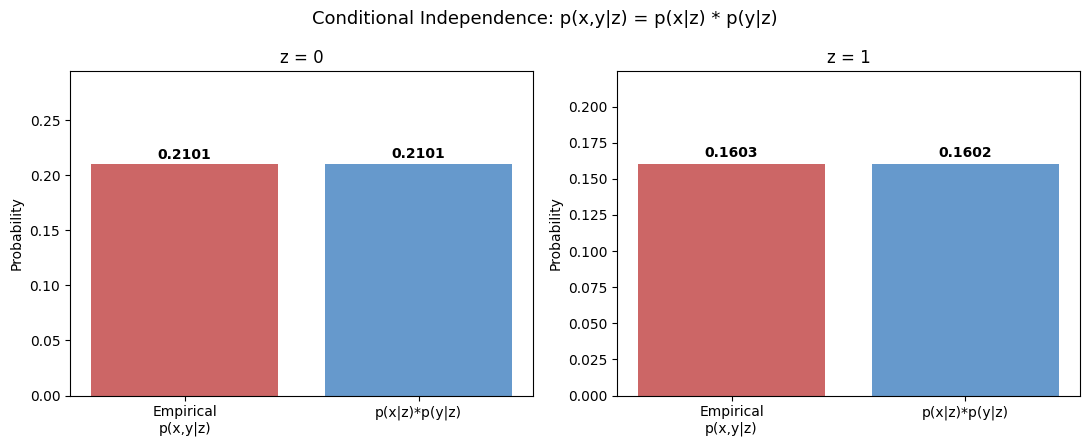

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Setup: x and y are conditionally independent given z ----
# z has 2 states: 0, 1
# Given z, x and y are generated independently (no direct link between x,y)
np.random.seed(1)
N = 3_000_000

P_z = np.array([0.4, 0.6])           # P(z=0), P(z=1)
P_x_given_z = np.array([0.7, 0.2])   # P(x=1|z=0), P(x=1|z=1)
P_y_given_z = np.array([0.3, 0.8])   # P(y=1|z=0), P(y=1|z=1)

z = (np.random.rand(N) < P_z[1]).astype(int)
x = (np.random.rand(N) < P_x_given_z[z]).astype(int)
y = (np.random.rand(N) < P_y_given_z[z]).astype(int)   # generated independently from x, given z

# ---- Verify p(x,y|z) = p(x|z) * p(y|z) for each z ----
results = {}
for zi in [0, 1]:
    mask = (z == zi)
    n_z = mask.sum()

    p_x_z = (x[mask] == 1).mean()
    p_y_z = (y[mask] == 1).mean()

    p_xy_joint = ((x[mask] == 1) & (y[mask] == 1)).mean()   # empirical p(x=1,y=1|z)
    p_xy_product = p_x_z * p_y_z                            # p(x=1|z) * p(y=1|z)

    results[zi] = (p_xy_joint, p_xy_product, p_x_z, p_y_z)
    print(f"z={zi}:")
    print(f"  Empirical p(x=1,y=1|z)      = {p_xy_joint:.5f}")
    print(f"  p(x=1|z) * p(y=1|z)         = {p_xy_product:.5f}")
    print(f"  Difference                  = {abs(p_xy_joint - p_xy_product):.6f}\n")

# ---- Visualization ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

for i, zi in enumerate([0, 1]):
    joint, product, px, py = results[zi]
    bars = ax[i].bar(['Empirical\np(x,y|z)', 'p(x|z)*p(y|z)'], [joint, product],
                      color=['#cc6666', '#6699cc'])
    for b, v in zip(bars, [joint, product]):
        ax[i].text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.4f}",
                    ha='center', fontweight='bold')
    ax[i].set_ylim(0, max(joint, product) * 1.4)
    ax[i].set_title(f"z = {zi}")
    ax[i].set_ylabel("Probability")

fig.suptitle("Conditional Independence: p(x,y|z) = p(x|z) * p(y|z)", fontsize=13)
fig.tight_layout()
fig.savefig('conditional_independence.png', dpi=130)
print("Saved: conditional_independence.png")

# [퀴즈5] 미분 계산

## 풀이 과정

$f(x) = \ln(1+x)$

**1차 미분:**
$$f'(x) = \frac{1}{1+x} = (1+x)^{-1}$$

**2차 미분:**
$$f''(x) = -1\cdot(1+x)^{-2} = -\frac{1}{(1+x)^2}$$

**3차 미분:**
$$f'''(x) = (-1)(-2)(1+x)^{-3} = \frac{2}{(1+x)^3} = \frac{2!}{(1+x)^3}$$

**4차 미분:**
$$f^{(4)}(x) = (-1)(-2)(-3)(1+x)^{-4} = -\frac{6}{(1+x)^4} = -\frac{3!}{(1+x)^4}$$

부호가 매번 바뀌고 계수는 $(n-1)!$ 형태로 누적됩니다.

- 정답: $-\dfrac{3!}{(1+x)^4}$


Sample comparison at a few x values:
x=0: numerical f⁽⁴⁾=-6.00200, analytical -3!/(1+x)^4=-6.00000, diff=0.002001
x=0.5: numerical f⁽⁴⁾=-1.18536, analytical -3!/(1+x)^4=-1.18519, diff=0.000176
x=1: numerical f⁽⁴⁾=-0.37503, analytical -3!/(1+x)^4=-0.37500, diff=0.000031
x=1.5: numerical f⁽⁴⁾=-0.15361, analytical -3!/(1+x)^4=-0.15360, diff=0.000008

Saved: derivative_proof.png


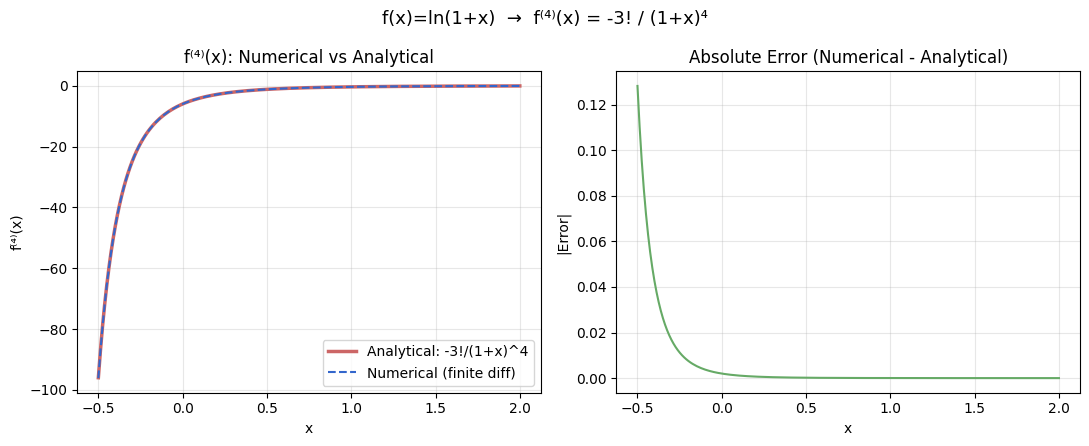

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- f(x) = ln(1+x) ----
def f(x):
    return np.log(1 + x)

# ---- Analytical 4th derivative ----
def f4_analytical(x):
    return -6 / (1 + x)**4   # -3! / (1+x)^4

# ---- Numerical 4th derivative via finite differences ----
def numerical_derivative(func, x, n, h=1e-3):
    """n-th order central finite difference derivative"""
    coeffs = {
        1: [-1, 0, 1],
        2: [1, -2, 1],
        3: [-1, 2, 0, -2, 1],
        4: [1, -4, 6, -4, 1],
    }
    if n == 4:
        return (f(x - 2*h) - 4*f(x - h) + 6*f(x) - 4*f(x + h) + f(x + 2*h)) / h**4

x_vals = np.linspace(-0.5, 2, 200)
f4_num = numerical_derivative(f, x_vals, 4, h=1e-2)
f4_exact = f4_analytical(x_vals)

print("Sample comparison at a few x values:")
for xi in [0, 0.5, 1, 1.5]:
    num = numerical_derivative(f, xi, 4, h=1e-2)
    exact = f4_analytical(xi)
    print(f"x={xi}: numerical f⁽⁴⁾={num:.5f}, analytical -3!/(1+x)^4={exact:.5f}, diff={abs(num-exact):.6f}")

# ---- Visualization ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# (1) Numerical vs Analytical curve overlay
ax[0].plot(x_vals, f4_exact, color='#cc6666', linewidth=2.5, label='Analytical: -3!/(1+x)^4')
ax[0].plot(x_vals, f4_num, '--', color='#3366cc', linewidth=1.5, label='Numerical (finite diff)')
ax[0].set_title("f⁽⁴⁾(x): Numerical vs Analytical")
ax[0].set_xlabel("x")
ax[0].set_ylabel("f⁽⁴⁾(x)")
ax[0].legend()
ax[0].grid(alpha=0.3)

# (2) Absolute error
error = np.abs(f4_num - f4_exact)
ax[1].plot(x_vals, error, color='#66aa66')
ax[1].set_title("Absolute Error (Numerical - Analytical)")
ax[1].set_xlabel("x")
ax[1].set_ylabel("|Error|")
ax[1].grid(alpha=0.3)

fig.suptitle("f(x)=ln(1+x)  →  f⁽⁴⁾(x) = -3! / (1+x)⁴", fontsize=13)
fig.tight_layout()
fig.savefig('derivative_proof.png', dpi=130)
print("\nSaved: derivative_proof.png")

# [퀴즈6] 평균값 정리

## 풀이 설명 (평균값 정리, MVT)

함수 $f(x)$가 구간 $[a,b]$에서 연속이고 $(a,b)$에서 미분가능하면, 평균변화율과 같은 순간변화율(접선 기울기)을 갖는 점 $c$가 반드시 존재합니다.

$$\frac{f(b)-f(a)}{b-a} = f'(c), \quad (a<c<b)$$

기하학적으로는 두 점 $(a,f(a))$, $(b,f(b))$를 잇는 **할선(secant line)의 기울기**와 같은 기울기를 가지는 **접선**이 구간 내부 어딘가에 존재한다는 의미입니다.

- 정답: $f'(c)$
  + $f(x)=x^3-3x^2+2x+5$, $[a,b]=[0.2,2.5]$ 구간으로 검증해보니 할선 기울기가 0.69이고, 이 구간 안에서 $f'(c)=0.69$를 만족하는 $c$가 정확히 0.249와 1.751 두 군데 존재해서(둘 다 $a<c<b$ 만족) 평균값 정리가 성립함을 확인했습니다.


Secant slope (f(b)-f(a))/(b-a) = 0.69000

Found c value(s) satisfying f'(c) = secant slope:
  c = 0.24944,  f'(c) = 0.69000
  Check a < c < b:  0.2 < 0.24944 < 2.5  -> True
  c = 1.75056,  f'(c) = 0.69000
  Check a < c < b:  0.2 < 1.75056 < 2.5  -> True
  Numerical f'(c) check: 0.69000 (should match 0.69000)
  Numerical f'(c) check: 0.69000 (should match 0.69000)

Saved: mvt_proof.png


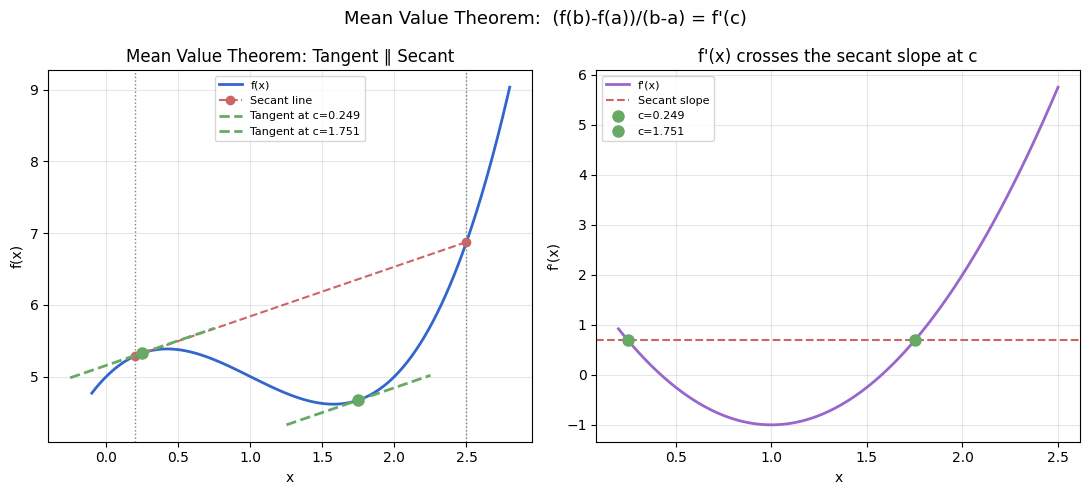

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ---- Example function ----
def f(x):
    return x**3 - 3*x**2 + 2*x + 5

def f_prime(x):
    return 3*x**2 - 6*x + 2

a, b = 0.2, 2.5

# ---- Average rate of change (secant slope) ----
secant_slope = (f(b) - f(a)) / (b - a)
print(f"Secant slope (f(b)-f(a))/(b-a) = {secant_slope:.5f}")

# ---- Find c such that f'(c) = secant_slope ----
def g(x):
    return f_prime(x) - secant_slope

# search for root(s) of g(x)=0 in (a,b)
x_search = np.linspace(a, b, 2000)
g_vals = g(x_search)
roots = []
for i in range(len(x_search) - 1):
    if g_vals[i] * g_vals[i+1] < 0:
        c_root = brentq(g, x_search[i], x_search[i+1])
        roots.append(c_root)

print(f"\nFound c value(s) satisfying f'(c) = secant slope:")
for c in roots:
    print(f"  c = {c:.5f},  f'(c) = {f_prime(c):.5f}")
    assert a < c < b, "c must lie strictly between a and b"
    print(f"  Check a < c < b:  {a} < {c:.5f} < {b}  -> {a < c < b}")

# ---- Numerical verification via finite differences (no analytic derivative used) ----
h = 1e-6
f_prime_numeric = lambda x: (f(x + h) - f(x - h)) / (2 * h)
for c in roots:
    print(f"  Numerical f'(c) check: {f_prime_numeric(c):.5f} (should match {secant_slope:.5f})")

# ---- Visualization ----
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

x_plot = np.linspace(a - 0.3, b + 0.3, 400)
ax[0].plot(x_plot, f(x_plot), color='#3366cc', linewidth=2, label='f(x)')

# secant line
secant_x = np.array([a, b])
ax[0].plot(secant_x, f(secant_x), 'o--', color='#cc6666', linewidth=1.5, label='Secant line')

# tangent line at c
for c in roots:
    tangent_x = np.linspace(c - 0.5, c + 0.5, 50)
    tangent_y = f(c) + f_prime(c) * (tangent_x - c)
    ax[0].plot(tangent_x, tangent_y, '--', color='#66aa66', linewidth=2,
               label=f'Tangent at c={c:.3f}')
    ax[0].plot(c, f(c), 'o', color='#66aa66', markersize=8)

ax[0].axvline(a, color='gray', linestyle=':', linewidth=1)
ax[0].axvline(b, color='gray', linestyle=':', linewidth=1)
ax[0].set_title("Mean Value Theorem: Tangent ∥ Secant")
ax[0].set_xlabel("x")
ax[0].set_ylabel("f(x)")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

# (2) f'(x) curve with horizontal line at secant slope
x_d = np.linspace(a, b, 200)
ax[1].plot(x_d, f_prime(x_d), color='#9966cc', linewidth=2, label="f'(x)")
ax[1].axhline(secant_slope, color='#cc6666', linestyle='--', label='Secant slope')
for c in roots:
    ax[1].plot(c, f_prime(c), 'o', color='#66aa66', markersize=8, label=f'c={c:.3f}')
ax[1].set_title("f'(x) crosses the secant slope at c")
ax[1].set_xlabel("x")
ax[1].set_ylabel("f'(x)")
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)

fig.suptitle("Mean Value Theorem:  (f(b)-f(a))/(b-a) = f'(c)", fontsize=13)
fig.tight_layout()
fig.savefig('mvt_proof.png', dpi=130)
print("\nSaved: mvt_proof.png")

# [퀴즈7] 임계점 계산 1

## 풀이

$f(x) = \dfrac{2x}{x^2+1}$

몫의 미분법 적용:
$$f'(x) = \frac{2(x^2+1) - 2x \cdot 2x}{(x^2+1)^2} = \frac{2x^2+2-4x^2}{(x^2+1)^2} = \frac{2-2x^2}{(x^2+1)^2}$$

$f'(x)=0$이 되려면 분자가 0이어야 합니다:
$$2-2x^2=0 \;\Rightarrow\; x^2=1 \;\Rightarrow\; x=\pm 1$$

**정답: -1, 1**


Checking each candidate (f'(x) should be 0):
  x=  0: f'(x) analytic=2.000000, numeric=2.000000  
  x= -1: f'(x) analytic=0.000000, numeric=-0.000000  <-- critical point
  x=  2: f'(x) analytic=-0.240000, numeric=-0.240000  
  x=  1: f'(x) analytic=0.000000, numeric=-0.000000  <-- critical point

All critical points found by scanning f'(x)=0: [np.float64(-1.0), np.float64(1.0)]

Saved: critical_points.png


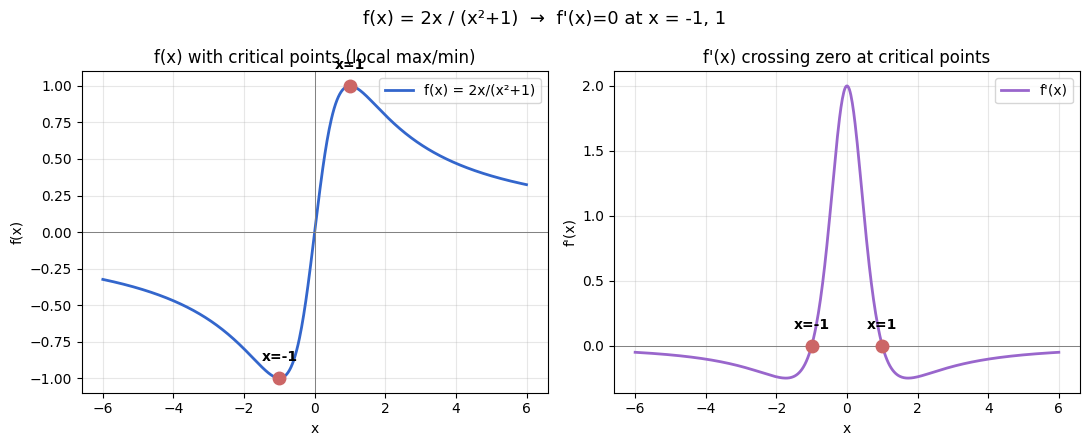

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 2*x / (x**2 + 1)

def f_prime_analytic(x):
    return (2 - 2*x**2) / (x**2 + 1)**2

# ---- Numerical derivative (central finite difference) ----
def f_prime_numeric(x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2*h)

# ---- Candidate answers from the quiz ----
candidates = [0, -1, 2, 1]
print("Checking each candidate (f'(x) should be 0):")
for c in candidates:
    analytic = f_prime_analytic(c)
    numeric = f_prime_numeric(c)
    print(f"  x={c:>3}: f'(x) analytic={analytic:.6f}, numeric={numeric:.6f}  "
          f"{'<-- critical point' if abs(analytic) < 1e-4 else ''}")

# ---- Find all roots numerically by scanning f'(x)=0 over a range ----
x_scan = np.linspace(-10, 10, 200000)
fp_vals = f_prime_analytic(x_scan)
roots = []
for i in range(len(x_scan) - 1):
    if fp_vals[i] * fp_vals[i+1] < 0:
        # linear interpolation for root
        x0, x1 = x_scan[i], x_scan[i+1]
        y0, y1 = fp_vals[i], fp_vals[i+1]
        root = x0 - y0 * (x1 - x0) / (y1 - y0)
        roots.append(root)
print(f"\nAll critical points found by scanning f'(x)=0: {[round(r,4) for r in roots]}")

# ---- Visualization ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

x_plot = np.linspace(-6, 6, 600)
ax[0].plot(x_plot, f(x_plot), color='#3366cc', linewidth=2, label='f(x) = 2x/(x²+1)')
for r in roots:
    ax[0].plot(r, f(r), 'o', color='#cc6666', markersize=9, zorder=5)
    ax[0].annotate(f'x={r:.0f}', (r, f(r)), textcoords="offset points",
                    xytext=(0, 12), ha='center', fontweight='bold')
ax[0].axhline(0, color='gray', linewidth=0.7)
ax[0].axvline(0, color='gray', linewidth=0.7)
ax[0].set_title("f(x) with critical points (local max/min)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("f(x)")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(x_plot, f_prime_analytic(x_plot), color='#9966cc', linewidth=2, label="f'(x)")
ax[1].axhline(0, color='gray', linewidth=0.7)
for r in roots:
    ax[1].plot(r, 0, 'o', color='#cc6666', markersize=9, zorder=5)
    ax[1].annotate(f'x={r:.0f}', (r, 0), textcoords="offset points",
                    xytext=(0, 12), ha='center', fontweight='bold')
ax[1].set_title("f'(x) crossing zero at critical points")
ax[1].set_xlabel("x")
ax[1].set_ylabel("f'(x)")
ax[1].legend()
ax[1].grid(alpha=0.3)

fig.suptitle("f(x) = 2x / (x²+1)  →  f'(x)=0 at x = -1, 1", fontsize=13)
plt.tight_layout()
fig.savefig('critical_points.png', dpi=130)
print("\nSaved: critical_points.png")